# Opinion pooling

[Entropy pooling](07_Entropy_Pooling.md) turns *one* set of views into a reweighted prior. But
in practice you often have *several* views from different sources — a fundamental analyst, a
quant signal, a macro desk — and they may disagree. **Opinion pooling** combines several
entropy-pooling posteriors into a single consensus prior, weighting each opinion by how much
you trust it. It is the natural capstone of the view-prior arc: each opinion is itself an
`EntropyPoolingPrior`, and the pool blends them.

`PortfolioOptimisers` implements it as `OpinionPoolingPrior`: you pass a vector of
entropy-pooling priors as `pes`, optional credibility weights `w`, a pooling algorithm
(`LinearOpinionPooling` or `LogarithmicOpinionPooling`), and an optional robust
confidence `p`. This page is a deep dive: we build three opinions, pool them, then work through
every lever the pool exposes — the two pooling algorithms, the credibility weights and their
uniform-prior fallback, and robust pooling that automatically discounts outlier opinions.

> **When to reach for this**
>
> Reach for opinion pooling when you have multiple, possibly conflicting, sets of views and
> want a principled consensus rather than picking a winner or hand-averaging forecasts.
> Assign each opinion a weight reflecting its credibility; the pool degrades gracefully when
> opinions disagree. If you only have a single coherent set of views, plain entropy pooling
> is enough; if your views are mean-only and Gaussian, Black–Litterman is lighter still.

In [1]:
using PortfolioOptimisers, PrettyTables

mmtfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v*100, digits=4)) %" : v
    end
end;
resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v*100, digits=3)) %" : v
    end
end;

## 1. ReturnsResult data

We use the same S&P 500 slice as the other examples.

In [2]:
using CSV, TimeSeries, DataFrames

X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)

sets = AssetSets(;
                 dict = Dict("nx" => rd.nx, "tech" => ["AAPL", "AMD", "MSFT"],
                             "energy" => ["CVX"]))

AssetSets
   key ┼ String: "nx"
  ukey ┼ String: "ux"
  dict ┴ Dict{String, Vector{String}}: Dict("nx" => ["AAPL", "AMD", "BAC", "BBY", "CVX", "GE", "HD", "JNJ", "JPM", "KO", "LLY", "MRK", "MSFT", "PEP", "PFE", "PG", "RRC", "UNH", "WMT", "XOM"], "tech" => ["AAPL", "AMD", "MSFT"], "energy" => ["CVX"])


## 2. Three opinions

Each opinion is an `EntropyPoolingPrior` with its own views — think of them as three
analysts who looked at the same market and came to different conclusions:

  - **Opinion A** (bullish Apple): `AAPL == 0.0008`.
  - **Opinion B** (sector call): tech beats energy, and Microsoft does well.
  - **Opinion C** (defensive): pin down a couple of low-vol names.

In [3]:
opinion_a = EntropyPoolingPrior(; sets = sets,
                                mu_views = LinearConstraintEstimator(;
                                                                     val = ["AAPL == 0.0008"]))
opinion_b = EntropyPoolingPrior(; sets = sets,
                                mu_views = LinearConstraintEstimator(;
                                                                     val = ["tech >= energy",
                                                                            "MSFT == 0.0006"]))
opinion_c = EntropyPoolingPrior(; sets = sets,
                                mu_views = LinearConstraintEstimator(;
                                                                     val = ["JNJ == 0.0004",
                                                                            "KO == 0.0003"]))

EntropyPoolingPrior
           pe ┼ EmpiricalPrior
              │        ce ┼ PortfolioOptimisersCovariance
              │           │   ce ┼ Covariance
              │           │      │    me ┼ SimpleExpectedReturns
              │           │      │       │   w ┴ nothing
              │           │      │    ce ┼ GeneralCovariance
              │           │      │       │   ce ┼ SimpleCovariance: SimpleCovariance(true)
              │           │      │       │    w ┴ nothing
              │           │      │   alg ┴ FullMoment()
              │           │   mp ┼ MatrixProcessing
              │           │      │     pdm ┼ Posdef
              │           │      │         │      alg ┼ UnionAll: NearestCorrelationMatrix.Newton
              │           │      │         │   kwargs ┴ @NamedTuple{}: NamedTuple()
              │           │      │      dn ┼ nothing
              │           │      │      dt ┼ nothing
              │           │      │     alg ┼ nothing
            

## 3. Pooling the opinions

We pool the three with credibility weights — we trust the Apple call most, the sector call
next, the defensive call least. The weights are normalised internally.

In [4]:
op = OpinionPoolingPrior(; pes = [opinion_a, opinion_b, opinion_c], w = [0.5, 0.3, 0.2])

OpinionPoolingPrior
  pes ┼ 3-element Vector{EntropyPoolingPrior}
      │ EntropyPoolingPrior ⋯
      │ EntropyPoolingPrior ⋯
      │ EntropyPoolingPrior ⋯
  pe1 ┼ nothing
  pe2 ┼ EmpiricalPrior
      │        ce ┼ PortfolioOptimisersCovariance
      │           │   ce ┼ Covariance
      │           │      │    me ┼ SimpleExpectedReturns
      │           │      │       │   w ┴ nothing
      │           │      │    ce ┼ GeneralCovariance
      │           │      │       │   ce ┼ SimpleCovariance: SimpleCovariance(true)
      │           │      │       │    w ┴ nothing
      │           │      │   alg ┴ FullMoment()
      │           │   mp ┼ MatrixProcessing
      │           │      │     pdm ┼ Posdef
      │           │      │         │      alg ┼ UnionAll: NearestCorrelationMatrix.Newton
      │           │      │         │   kwargs ┴ @NamedTuple{}: NamedTuple()
      │           │      │      dn ┼ nothing
      │           │      │      dt ┼ nothing
      │           │      │     al

## 4. Consensus vs individual opinions

We compute each opinion's posterior and the pooled consensus, and compare their expected
returns against the plain empirical prior. The consensus reflects every opinion in proportion
to its weight, without any single one dominating.

In [5]:
pr_emp = prior(EmpiricalPrior(), rd)
pr_a = prior(opinion_a, rd)
pr_b = prior(opinion_b, rd)
pr_c = prior(opinion_c, rd)
pr_op = prior(op, rd)

pretty_table(DataFrame(["Assets" => rd.nx, "Empirical" => pr_emp.mu, "Opinion A" => pr_a.mu,
                        "Opinion B" => pr_b.mu, "Opinion C" => pr_c.mu,
                        "Pooled" => pr_op.mu]); formatters = [mmtfmt],
             title = "Expected returns: individual opinions vs pooled consensus")

      Expected returns: individual opinions vs pooled consensus
┌────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ Assets │ Empirical │ Opinion A │ Opinion B │ Opinion C │    Pooled │
│ String │   Float64 │   Float64 │   Float64 │   Float64 │   Float64 │
├────────┼───────────┼───────────┼───────────┼───────────┼───────────┤
│   AAPL │ -0.1126 % │    0.08 % │  0.0764 % │ -0.1273 % │  0.0375 % │
│    AMD │ -0.2809 % │ -0.0392 % │  0.0591 % │ -0.3038 % │ -0.0626 % │
│    BAC │ -0.0934 % │  0.0062 % │  0.0113 % │ -0.1048 % │ -0.0145 % │
│    BBY │ -0.0279 % │  0.1019 % │  0.1194 % │ -0.0428 % │  0.0782 % │
│    CVX │  0.1945 % │  0.2456 % │  0.1955 % │  0.1892 % │  0.2193 % │
│     GE │ -0.0339 % │  0.0688 % │  0.0751 % │ -0.0474 % │  0.0475 % │
│     HD │ -0.0707 % │  0.0303 % │  0.0441 % │ -0.0823 % │  0.0119 % │
│    JNJ │  0.0307 % │  0.0646 % │  0.0589 % │    0.04 % │   0.058 % │
│    JPM │ -0.0417 % │  0.0473 % │  0.0523 % │ -0.0511 % │  0.0291 % │
│     KO │  0

Pooled consensus expected returns.

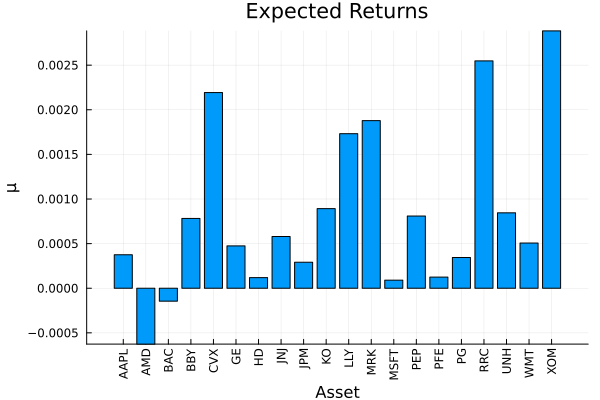

In [6]:
using StatsPlots, GraphRecipes
plot_mu(pr_op, rd.nx)

## 5. Linear vs logarithmic pooling

The pooling `alg` controls *how* the opinion distributions are combined.

  - `LinearOpinionPooling` (default) takes a **weighted arithmetic average** of the
    opinion probabilities. It is the "mixture of experts" rule — the consensus is a blend, so a
    single confident opinion can pull the mean a long way.
  - `LogarithmicOpinionPooling` takes a **weighted geometric mean** (the
    Kullback–Leibler-optimal consensus). It is more consensus-seeking: an asset only moves far
    if the opinions *agree*, so disagreement is damped.

The two agree closely when the opinions are compatible and diverge as they conflict.

In [7]:
pr_lin = prior(OpinionPoolingPrior(; pes = [opinion_a, opinion_b, opinion_c],
                                   w = [0.5, 0.3, 0.2], alg = LinearOpinionPooling()), rd)
pr_log = prior(OpinionPoolingPrior(; pes = [opinion_a, opinion_b, opinion_c],
                                   w = [0.5, 0.3, 0.2], alg = LogarithmicOpinionPooling()),
               rd)

pretty_table(DataFrame(["Assets" => rd.nx, "Linear pool" => pr_lin.mu,
                        "Logarithmic pool" => pr_log.mu]); formatters = [mmtfmt],
             title = "Linear vs logarithmic pooling")

       Linear vs logarithmic pooling
┌────────┬─────────────┬──────────────────┐
│ Assets │ Linear pool │ Logarithmic pool │
│ String │     Float64 │          Float64 │
├────────┼─────────────┼──────────────────┤
│   AAPL │    0.0375 % │         0.0367 % │
│    AMD │   -0.0626 % │        -0.0635 % │
│    BAC │   -0.0145 % │        -0.0148 % │
│    BBY │    0.0782 % │         0.0781 % │
│    CVX │    0.2193 % │         0.2193 % │
│     GE │    0.0475 % │         0.0475 % │
│     HD │    0.0119 % │         0.0114 % │
│    JNJ │     0.058 % │         0.0579 % │
│    JPM │    0.0291 % │         0.0289 % │
│     KO │    0.0892 % │         0.0891 % │
│    LLY │    0.1732 % │         0.1731 % │
│    MRK │    0.1878 % │         0.1878 % │
│   MSFT │    0.0091 % │         0.0085 % │
│    PEP │    0.0809 % │          0.081 % │
│      ⋮ │           ⋮ │                ⋮ │
└────────┴─────────────┴──────────────────┘
                             6 rows omitted


## 6. Credibility weights and the uniform-prior fallback

The weights `w` say how credible each opinion is. They have a property worth knowing: if they
sum to **less than one**, the remaining weight is assigned to the **uniform prior** (the
unreweighted empirical distribution). So `w` is not just a relative split — its *total* is a
global confidence dial. Shrinking the total pulls the consensus back toward the data and away
from the views. Below we hold the relative trust fixed (5:3:2) but scale the total from 1.0 down
to 0.3, watching the pooled expected returns retreat toward the empirical prior.

In [8]:
scales = [1.0, 0.7, 0.4]
pr_scaled = [prior(OpinionPoolingPrior(; pes = [opinion_a, opinion_b, opinion_c],
                                       w = s .* [0.5, 0.3, 0.2]), rd) for s in scales]

i_aapl = findfirst(==("AAPL"), rd.nx)
i_msft = findfirst(==("MSFT"), rd.nx)
pretty_table(DataFrame("weight total" => ["empirical (0.0)"; string.(scales)],
                       "AAPL posterior" => [pr_emp.mu[i_aapl];
                                            [p.mu[i_aapl] for p in pr_scaled]],
                       "MSFT posterior" => [pr_emp.mu[i_msft];
                                            [p.mu[i_msft] for p in pr_scaled]]);
             formatters = [mmtfmt],
             title = "Lower total weight shrinks the consensus toward the empirical prior")

Lower total weight shrinks the consensus toward the empirical prior
┌─────────────────┬────────────────┬────────────────┐
│    weight total │ AAPL posterior │ MSFT posterior │
│          String │        Float64 │        Float64 │
├─────────────────┼────────────────┼────────────────┤
│ empirical (0.0) │      -0.1126 % │      -0.1206 % │
│             1.0 │       0.0375 % │       0.0091 % │
│             0.7 │      -0.0075 % │      -0.0298 % │
│             0.4 │      -0.0526 % │      -0.0687 % │
└─────────────────┴────────────────┴────────────────┘


## 7. Robust pooling with `p`

Linear pooling trusts each opinion's weight as given. Setting `p` to a confidence in $(0, 1]$
turns on **robust opinion pooling**: each opinion's effective weight is adjusted by how far its
distribution sits from the consensus in Kullback–Leibler divergence, the idea being to discount
opinions that disagree sharply with the rest.

```julia
pr_robust = prior(OpinionPoolingPrior(; pes = [opinion_a, opinion_b, opinion_c],
                                      w = [0.5, 0.3, 0.2], p = 0.1), rd)
```

A caveat from dogfooding this page: on this S&P 500 slice the robust adjustment moved the
posterior *mean and covariance* only at the level of numerical noise ($\\sim 10^{-14}$),
even with a deliberately extreme fourth opinion. The KL discount reshapes the pooled *scenario
probabilities*, but with all opinions sharing the same return scenarios that barely propagates
into the first two moments here. Treat `p` as a lever that matters when opinions are
distributionally far apart, not as a reliable knob on the consensus mean for a short single
window — and reach for the credibility-weight total in section 6 when you want a dependable dial.

## 8. Why it matters: a consensus portfolio

Maximising the risk-adjusted ratio under the empirical prior and the pooled consensus shows how
the blended views reshape the portfolio — a single allocation that honours all three opinions
at once.

In [9]:
using Clarabel

slv = Solver(; name = :clarabel1, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))
rf = 4.2 / 100 / 252

res_emp = optimise(MeanRisk(; obj = MaximumRatio(; rf = rf),
                            opt = JuMPOptimiser(; pe = pr_emp, slv = slv)))
res_op = optimise(MeanRisk(; obj = MaximumRatio(; rf = rf),
                           opt = JuMPOptimiser(; pe = pr_op, slv = slv)))

pretty_table(DataFrame(["Assets" => rd.nx, "Empirical" => res_emp.w,
                        "Pooled consensus" => res_op.w]); formatters = [resfmt],
             title = "Maximum-ratio weights: empirical vs pooled consensus")

Maximum-ratio weights: empirical vs pooled consensus
┌────────┬───────────┬──────────────────┐
│ Assets │ Empirical │ Pooled consensus │
│ String │   Float64 │          Float64 │
├────────┼───────────┼──────────────────┤
│   AAPL │     0.0 % │            0.0 % │
│    AMD │     0.0 % │            0.0 % │
│    BAC │     0.0 % │            0.0 % │
│    BBY │     0.0 % │            0.0 % │
│    CVX │     0.0 % │            0.0 % │
│     GE │     0.0 % │            0.0 % │
│     HD │     0.0 % │            0.0 % │
│    JNJ │     0.0 % │            0.0 % │
│    JPM │     0.0 % │            0.0 % │
│     KO │     0.0 % │            0.0 % │
│    LLY │   0.002 % │          2.992 % │
│    MRK │  65.977 % │         64.458 % │
│   MSFT │     0.0 % │            0.0 % │
│    PEP │     0.0 % │            0.0 % │
│      ⋮ │         ⋮ │                ⋮ │
└────────┴───────────┴──────────────────┘
                           6 rows omitted


The composition plot makes the consensus tilt visible.

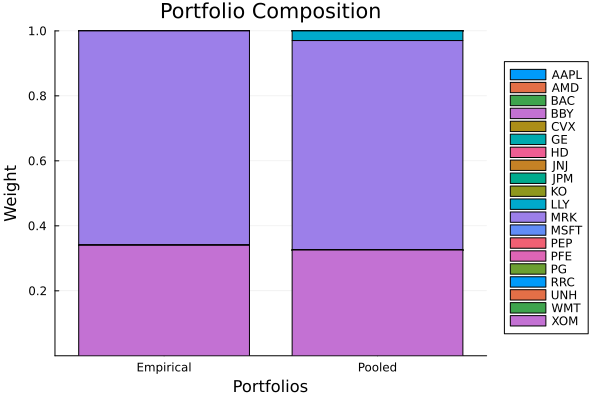

In [10]:
plot_stacked_bar_composition([res_emp, res_op], rd; xticks = (1:2, ["Empirical", "Pooled"]))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*